Connected to Python 3.12.10

In [ ]:
import joblib
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 0. You already have:
#    X = features_df   (linguistic features)
#    y = target        (0/1 engagement label)
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import xgboost as xgb
import shap

c:\Users\Wu\College_App_2028\SciFi_20260616\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ---------------------------------------------------------
# 1. Train/Test Split
# ---------------------------------------------------------
Xy = pd.read_parquet("03_merged_data.parquet") 
Xy = Xy.loc[Xy['engagement_label'].isin([0,2])]
Xy["engagement_binary"] = (Xy["engagement_label"] == 2).astype(int) 

feature_cols = ['token_count', 'unique_tokens', 'unique_lemmas', 'type_lemma_ratio', 'avg_word_len', 'hapax_ratio', 'noun_count', 
 'verb_count', 'adj_count', 'adv_count', 'avg_dep_depth', 'flesch_reading_ease', 'smog_index', 'ari',
 'coleman_liau', 'dale_chall', 'sentiment_proxy', 'sent_count', 'avg_sent_len', 'char_count', 'punctuation_count',
 'burstiness', 'concreteness_proxy', 'action_ratio']


X = Xy.loc[:, feature_cols]
y = Xy["engagement_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ---------------------------------------------------------
# 2. Standardize for Logistic Regression
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 3. Logistic Regression (interpretable baseline)
# ---------------------------------------------------------
logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_scaled, y_train)

#save model and scaler 
import joblib 
joblib.dump(logreg, "04_logit_model.joblib")
joblib.dump(scaler, "04_logit_scaler.joblib") 

#load model and scaler
#logreg = joblib.load("04_logit_model.joblib")
#scaler = joblib.load("04_logit_scaler.joblib")
#X_test_scaled = scaler.transform(X_test)
#y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]



# Predictions
y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression Performance ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Precision:", round(precision_score(y_test, y_pred_lr), 3))
print("Recall:", round(recall_score(y_test, y_pred_lr), 3))
print("F1:", round(f1_score(y_test, y_pred_lr), 3))
print("AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))


=== Logistic Regression Performance ===
Accuracy: 0.671
Precision: 0.644
Recall: 0.437
F1: 0.521
AUC: 0.705


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train model
log_clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000
)
log_clf.fit(X_train, y_train)

#save model
joblib.dump(log_clf, "04_logit_model.joblib") 


# Check performance
y_pred_proba = log_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", round(auc, 3))

AUC: 0.705


In [ ]:
# ---------------------------------------------------------
# 2. Standardize for Logistic Regression
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 3. Logistic Regression (interpretable baseline)
# ---------------------------------------------------------
logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_scaled, y_train)

#save model and scaler 
import joblib 
joblib.dump(logreg, "04_logit_model.joblib")
joblib.dump(scaler, "04_logit_scaler.joblib") 

#load model and scaler
#logreg = joblib.load("04_logit_model.joblib")
#scaler = joblib.load("04_logit_scaler.joblib")
#X_test_scaled = scaler.transform(X_test)
#y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]



# Predictions
y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression Performance ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Precision:", round(precision_score(y_test, y_pred_lr), 3))
print("Recall:", round(recall_score(y_test, y_pred_lr), 3))
print("F1:", round(f1_score(y_test, y_pred_lr), 3))
print("AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))


=== Logistic Regression Performance ===
Accuracy: 0.671
Precision: 0.644
Recall: 0.437
F1: 0.521
AUC: 0.705


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train model
log_clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000
)
log_clf.fit(X_train, y_train)

#save model
joblib.dump(log_clf, "04_logit_model_log_clf.joblib") 


# Check performance
y_pred_proba = log_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", round(auc, 3))

AUC: 0.705


In [ ]:
#---------------- set up shap -------------- 
import shap
# For classic Jupyter Notebook:
shap.initjs()

#--------------- choose the right shap explainer ------------
explainer = shap.Explainer(
    log_clf,
    X_train,
    feature_perturbation="interventional"
)

#shap_values = explainer.shap_values(X_test)
shap_values = explainer(X_test)

Background dataset has 181954 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=181954 when initializing the masker.
c:\Users\Wu\College_App_2028\SciFi_20260616\venv\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


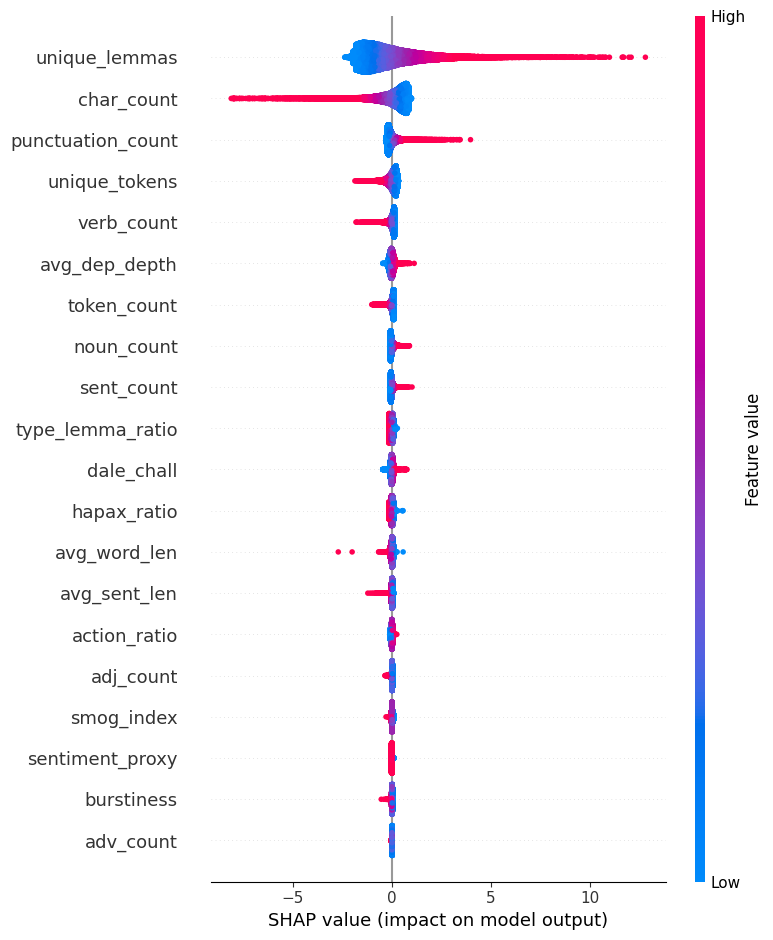

In [ ]:
# --------------- global feature importance ----------------
import matplotlib.pyplot as plt

# SHAP summary plot (global importance + direction)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    show=False
)
plt.tight_layout()
plt.show()

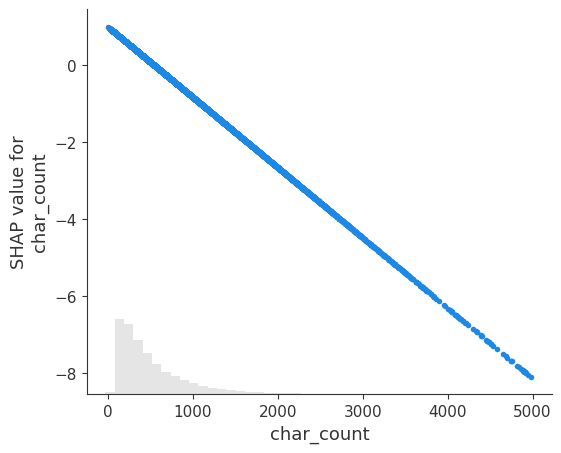

<Figure size 640x480 with 0 Axes>

In [ ]:
#feature_name = "flesch_reading_ease"
feature_name = "char_count"
shap.plots.scatter(shap_values[:, feature_name])
plt.tight_layout()
plt.show()

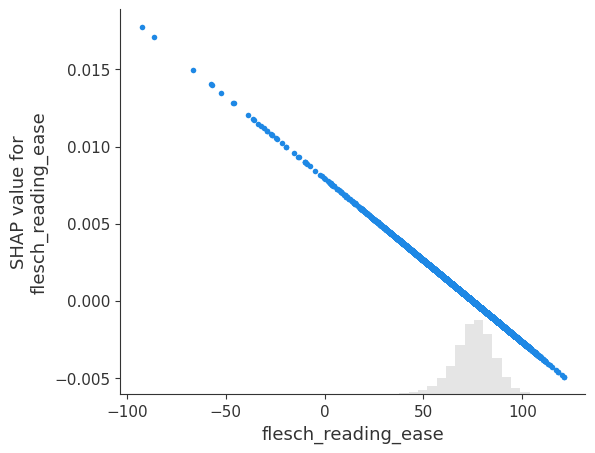

<Figure size 640x480 with 0 Axes>

In [ ]:
feature_name = "flesch_reading_ease"
#feature_name = "char_count"
shap.plots.scatter(shap_values[:, feature_name])
plt.tight_layout()
plt.show()

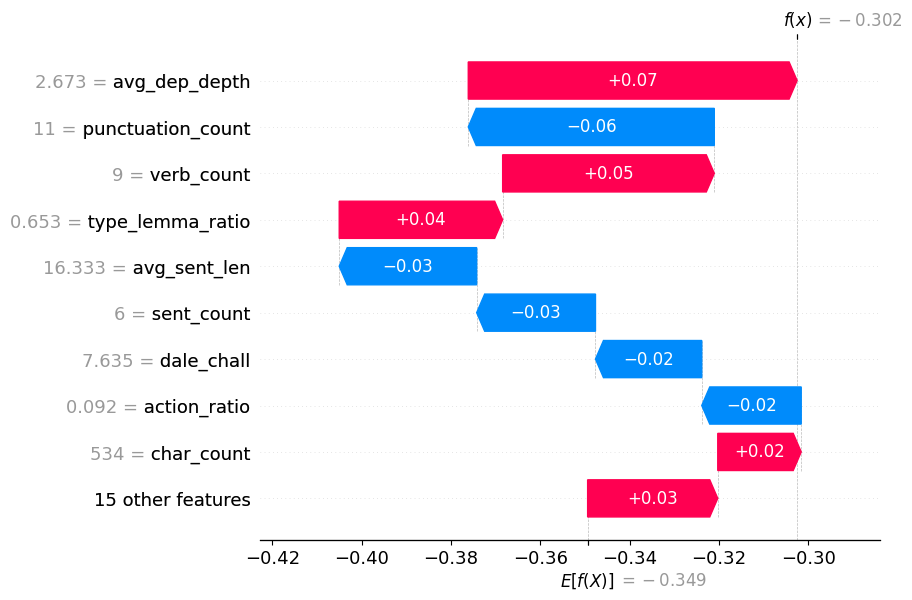

In [ ]:
i = 0  # index of the review you care about
shap.plots.waterfall(shap_values[i]) 

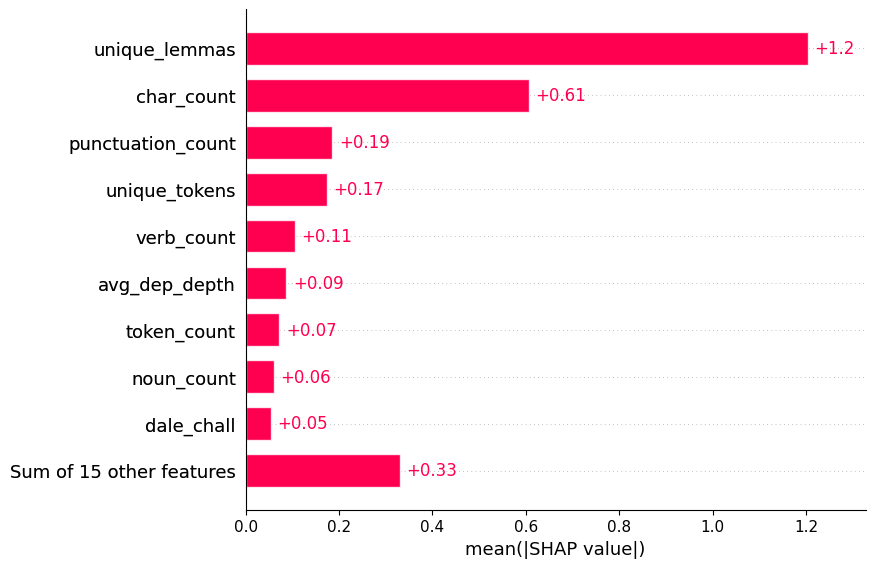

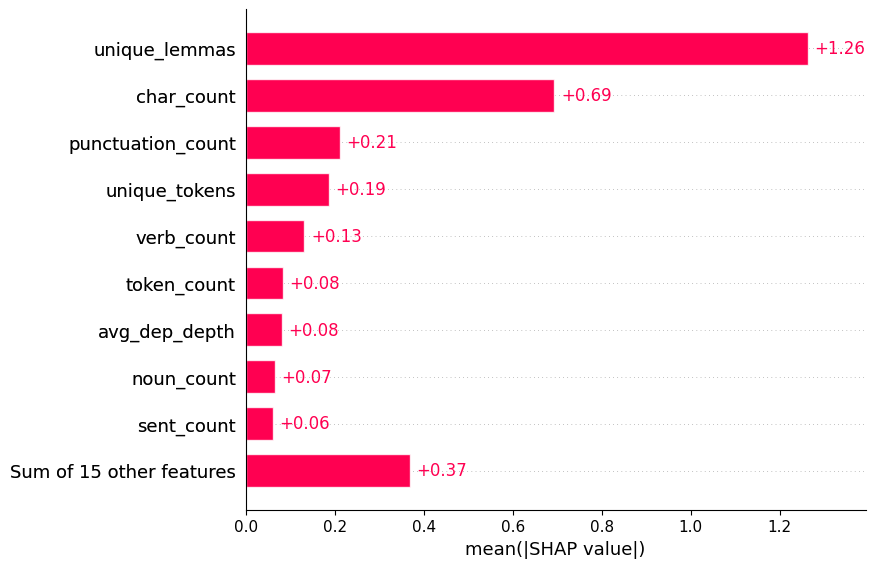

In [ ]:
""" segmented plot


this analysis is to answer - do linguistic features matter differently for high-star vs low-star reviews? 

- the model is trained only on linguistic features, not use star rating of reviews.
- the shap values reflect linguistic patterns only.
- the segmentation is based on review rating not used by the model.
- if the plots are similar, means the models learned linguistic signal is stable across star ratings. 

"""

meta_test = Xy.loc[X_test.index, :]

high_star_mask = meta_test["stars_review"] >= 4
low_star_mask  = meta_test["stars_review"] <= 2

shap_values_high = shap.Explanation(
    values = shap_values.values[high_star_mask],
    base_values = shap_values.base_values,
    data = shap_values.data[high_star_mask],
    feature_names = shap_values.feature_names
)

shap_values_low = shap.Explanation(
    values = shap_values.values[low_star_mask],
    base_values = shap_values.base_values,
    data = shap_values.data[low_star_mask],
    feature_names = shap_values.feature_names
)

shap.plots.bar(shap_values_high)
shap.plots.bar(shap_values_low)

In [ ]:
# ---------------------------------------------------------
# 5. Logistic Regression Coefficients (interpretability)
# ---------------------------------------------------------
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": logreg.coef_[0]
}).sort_values("coef", ascending=False)

print("\n=== Top Positive LR Coefficients ===")
print(coef_df.head(10))

print("\n=== Top Negative LR Coefficients ===")
print(coef_df.tail(10))


coef_df.to_excel("04_restaurant_logreg_coeff.xlsx")
coef_df.to_parquet("04_restaurant_logreg_coeff.parquet")


=== Top Positive LR Coefficients ===
                feature      coef
2         unique_lemmas  1.471739
20    punctuation_count  0.300289
0           token_count  0.243596
10        avg_dep_depth  0.104048
17           sent_count  0.083501
23         action_ratio  0.075323
15           dale_chall  0.073370
6            noun_count  0.042232
11  flesch_reading_ease  0.037043
13                  ari  0.018852

=== Top Negative LR Coefficients ===
             feature      coef
21        burstiness -0.017043
4       avg_word_len -0.022106
16   sentiment_proxy -0.026727
18      avg_sent_len -0.037311
8          adj_count -0.037352
3   type_lemma_ratio -0.063412
5        hapax_ratio -0.063942
1      unique_tokens -0.073291
7         verb_count -0.288791
19        char_count -1.110727
